# Project Setup

## Project Details (Add Project Name)


**Dataset:** German Credit Dataset — UCI 1994  
**Author:** Chuch  
**Date:** 2026-06-08  
**Objective:** What question is this notebook answering?  
**Status:** In Progress / Complete

## Environment and Imports

In [1]:
# ══════════════════════════════════════════════════════
# Environment Setup
# ══════════════════════════════════════════════════════

# ── Standard Library ──────────────────────────────────
import os
import sys
import warnings

# ── Data ──────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ── Machine Learning ──────────────────────────────────
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Jupyter ───────────────────────────────────────────
from IPython.core.interactiveshell import InteractiveShell
from IPython.display import display

def find_repo_root(start, repo_name='CreditRiskLearning'):
    path = os.path.abspath(start)
    while True:
        if os.path.basename(path) == repo_name:
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError(f"Could not find repo root: {repo_name}")
        path = parent

repo_root = find_repo_root(os.getcwd())
sys.path.append(os.path.join(repo_root, 'Core Resources'))
sys.path.append(os.path.join(repo_root, 'Core Resources', 'Scripts'))

import python_style_util as psu
import evaluation_utils as eu
import missingness_viz as mv        # missingess assessment functions

# ══════════════════════════════════════════════════════
# Display Settings
# ══════════════════════════════════════════════════════

%matplotlib inline

# Pandas
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'left')



# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Style Guide

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/style_guide_preview.png'

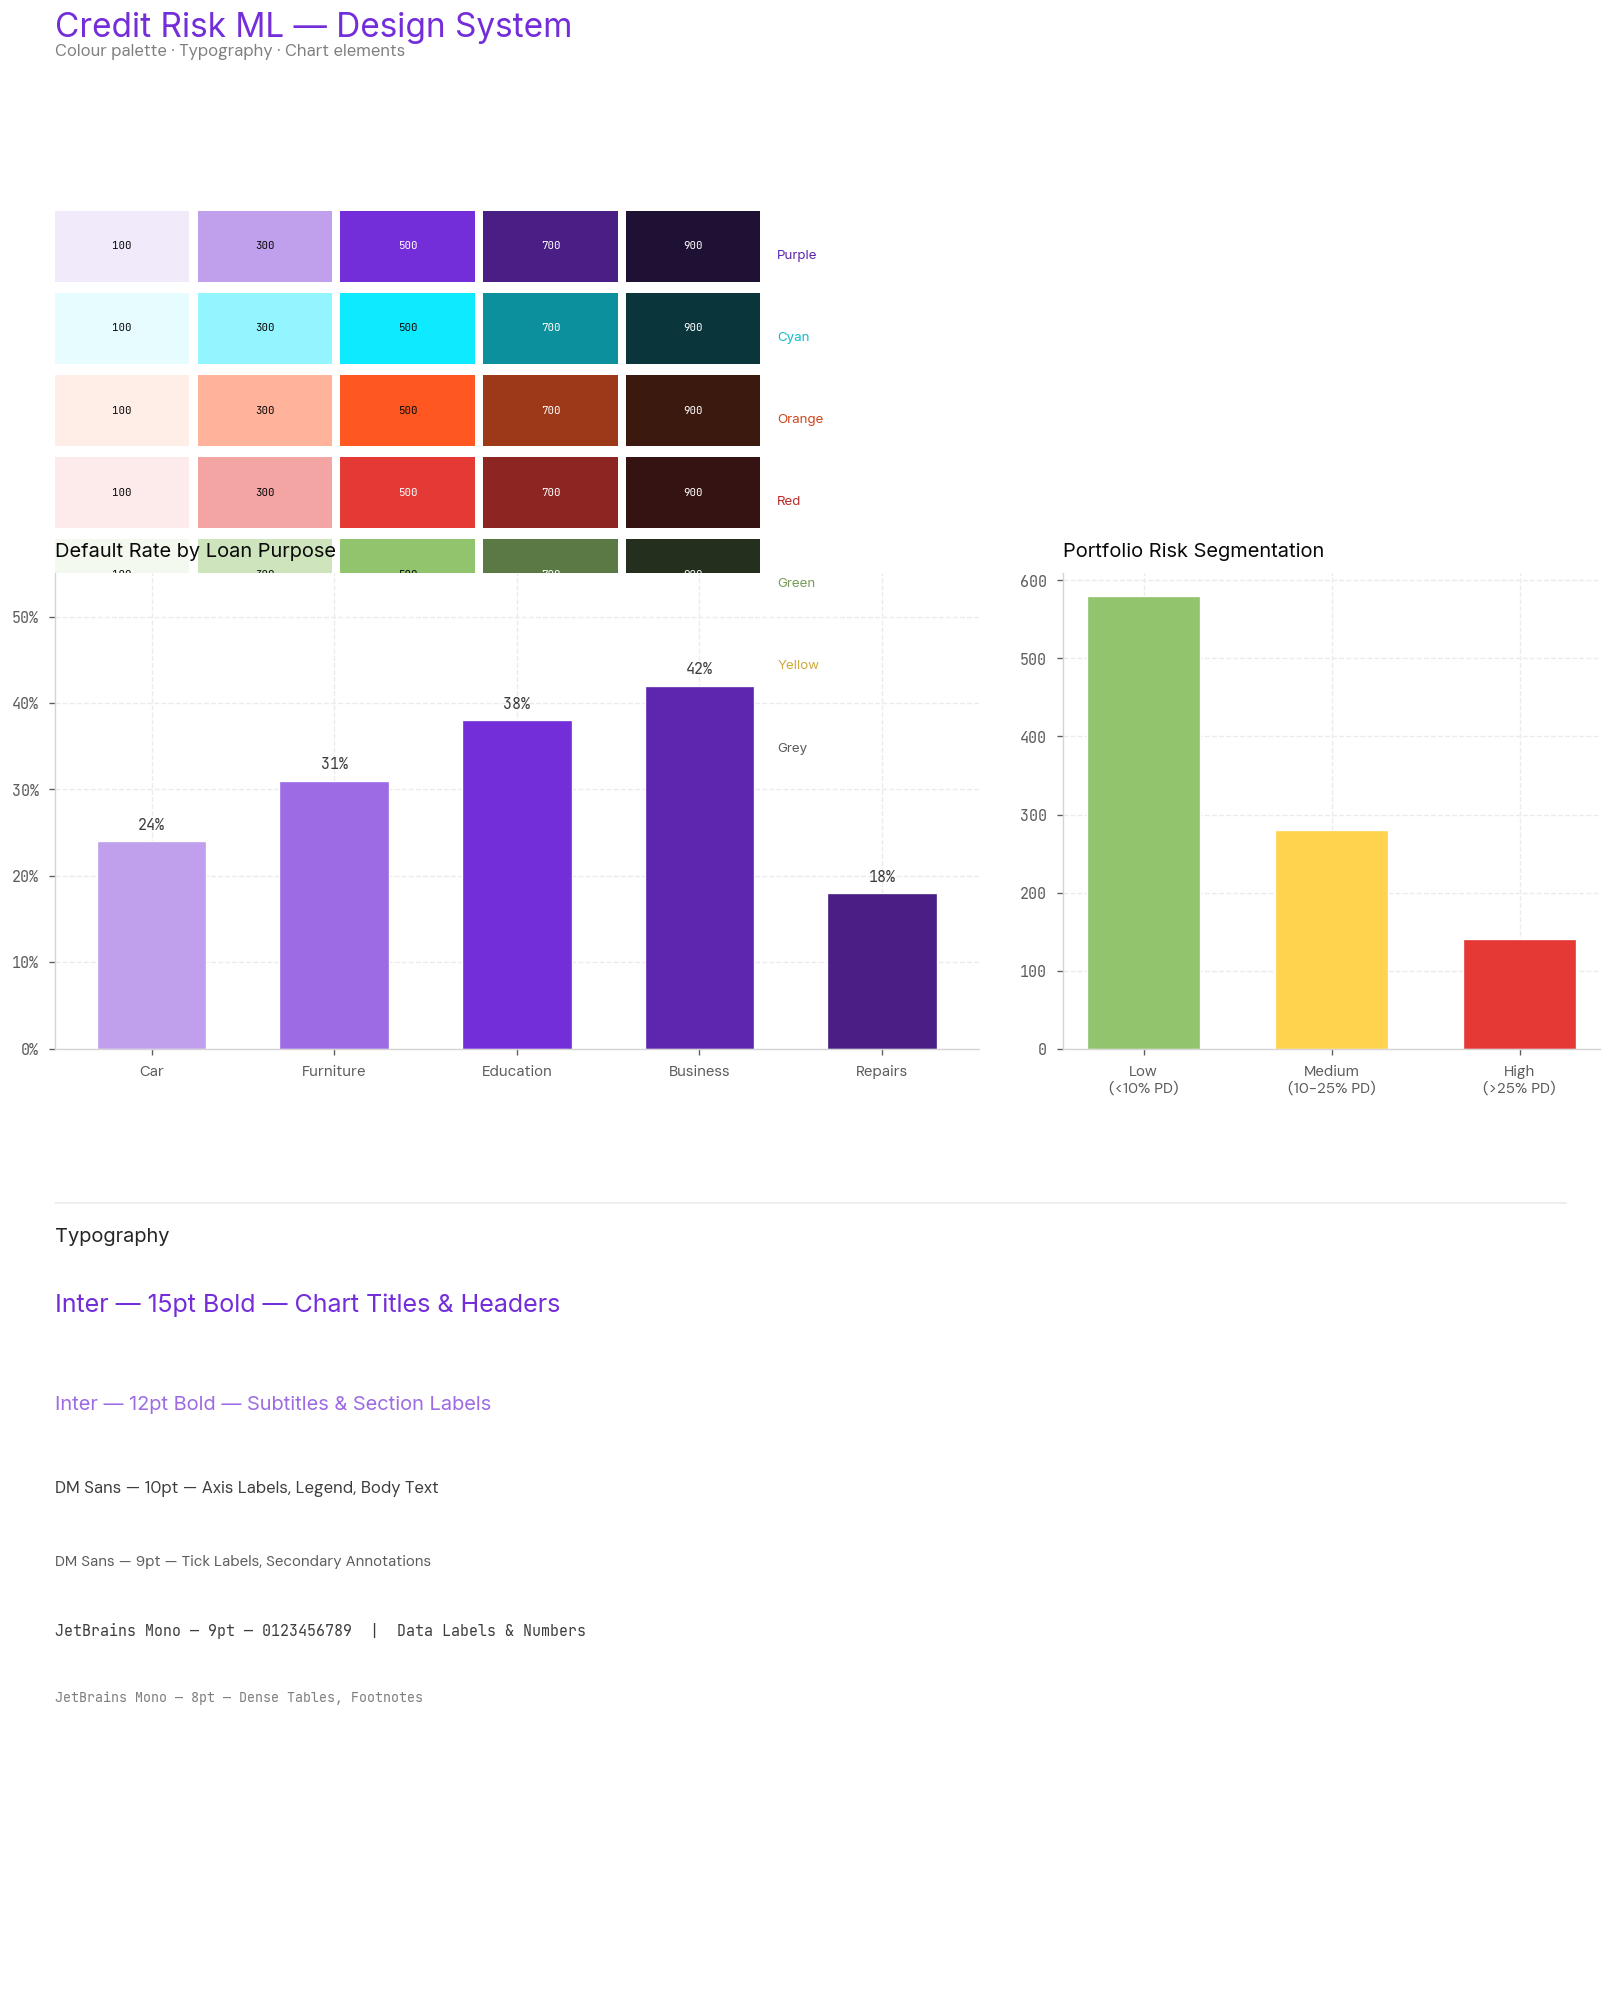

In [ ]:
psu.show_palette()
psu.show_fonts()
psu.show_tokens()

In [ ]:
import os

core = os.path.join(os.path.abspath('..'), 'Core Resources')
scripts = os.path.join(os.path.abspath('..'), 'Core Resources', 'Scripts')

print("Core Resources contents:")
print(os.listdir(core))

print("\nScripts contents:")
print(os.listdir(scripts) if os.path.exists(scripts) else "Scripts folder doesn't exist")

## Display Setttings

In [ ]:
# --- Pandas ---

pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places on floats
pd.set_option('display.max_columns', None)              # show all columns
pd.set_option('display.max_rows', 100)                  # show up to 100 rows
pd.set_option('display.width', None)                    # don't wrap wide dataframes
pd.set_option('display.colheader_justify', 'left')      # left-align column headers
pd.set_option('display.precision', 4)                   # decimal precision for describe()
pd.set_option('display.large_repr', 'truncate')         # truncate instead of summary for large dfs

# --- NumPy ---

np.set_printoptions(
    precision=4,        # decimal places (you have this)
    suppress=True,      # no scientific notation (you have this)
    linewidth=120,      # wrap width (you have this)
    threshold=1000,     # show up to 1000 elements before summarising with ...
    edgeitems=5,        # show 5 items at each end when it does summarise
)

# --- Matplotlib ---

%matplotlib inline
plt.rcParams['figure.dpi'] = 120             # sharper figures
plt.rcParams['savefig.dpi'] = 150            # higher res when saving
plt.rcParams['savefig.bbox'] = 'tight'       # no clipped labels when saving
plt.rcParams['savefig.facecolor'] = 'white'  # white background on saved figures

# --- Jupyter ---

InteractiveShell.ast_node_interactivity = 'all'  # print every expression, not just the last

# --- Warnings ---

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# --- Style ---

psu.set_style()

## Data Loading

In [ ]:
# Build path relative to notebook location
base_path = os.path.dirname(os.path.abspath('this_notebook.ipynb'))
data_path = os.path.join(base_path, 'German Credit Data', 'german.data')

# Load data
df = pd.read_csv('../Home Credit Default Risk/application_train.csv', sep=',')

# Project Body

## 1. Exploratory Data Analysis


### 1.1 Overview

In [ ]:
# ============================================
# SECTION 2: EDA
# ============================================

# --- Basic structure ---
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n')
print('Dtypes:')
print(df.dtypes.value_counts())          # how many numeric vs object/categorical

# --- Summary stats ---
# # numeric columns
psu.style_df(df.describe(include='object'))             # categorical columns (run separately)

### 1.2 The Target Variable

In [ ]:
# --- Target balance ---
TARGET = 'TARGET'   # Home Credit's default-flag column; change per dataset

target_counts = df[TARGET].value_counts()
target_rate = df[TARGET].mean()

print(target_counts)
print(f'\nDefault rate: {target_rate:.2%}')   # expect ~8% for Home Credit

plt.figure(figsize=(5, 4))
df[TARGET].value_counts().plot(kind='bar')
plt.title('Target distribution (0 = repaid, 1 = default)')
plt.xticks(rotation=0)
plt.show()

### 1.3 Missingness Assessment

In [ ]:
# --- Missing value summary ---
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(f'{len(missing_table)} columns have missing values\n')
missing_table.head(30)

### 1.4 Numeric Feature Distribution

In [ ]:
# --- Distributions of key numerics ---
num_cols = df.select_dtypes(include=[np.number]).columns.drop(TARGET, errors='ignore')

# Pick a handful to eyeball rather than plotting all 100+
key_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
key_cols = [c for c in key_cols if c in df.columns]

df[key_cols].hist(bins=50, figsize=(14, 8))
plt.tight_layout()
plt.show()

### 1.5 Feature vs Target Relationship

In [ ]:
# --- How a numeric feature relates to default ---
def plot_by_target(df, col, target=TARGET):
    plt.figure(figsize=(6, 4))
    for val in [0, 1]:
        df.loc[df[target] == val, col].plot(
            kind='kde', label=f'{target}={val}'
        )
    plt.title(f'{col} by {target}')
    plt.legend()
    plt.show()

# Example:
plot_by_target(df, 'EXT_SOURCE_2')   # external credit scores — strong predictors

## 2. Data Cleaning and Preprocessing


### 2.1 Fix Known Data Quality Issues

In [ ]:
# --- Fix known bad/placeholder values ---
# Home Credit: DAYS_EMPLOYED uses 365243 as a placeholder for "unemployed"
if 'DAYS_EMPLOYED' in df.columns:
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243)  # flag it first
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# DAYS_* columns are negative (days before application) — convert to positive years
for col in ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH']:
    if col in df.columns:
        df[col] = abs(df[col]) / 365

### 2.2 Drop Columns With Exxessive Missingness

In [ ]:
# --- Drop columns with excessive missingness ---
MISSING_THRESHOLD = 0.60   # drop columns >60% missing (tune per dataset)

missing_frac = df.isnull().mean()
cols_to_drop = missing_frac[missing_frac > MISSING_THRESHOLD].index.tolist()
cols_to_drop = [c for c in cols_to_drop if c != TARGET]

print(f'Dropping {len(cols_to_drop)} columns >{MISSING_THRESHOLD:.0%} missing')
df = df.drop(columns=cols_to_drop)

### Separate Features from Target

In [ ]:
# --- Split off the target and ID before processing features ---
ID_COL = 'SK_ID_CURR'   # Home Credit's applicant ID; change per dataset

y = df[TARGET]
X = df.drop(columns=[TARGET, ID_COL], errors='ignore')

# Identify column types for type-specific handling
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'{len(numeric_cols)} numeric, {len(categorical_cols)} categorical features')

### Leakage Safe Pre-Processing Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Numeric: median impute, then scale ---
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# --- Categorical: impute with a constant, then one-hot encode ---
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# --- Combine ---
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols),
])

## 3. Feature Engineering


### Domain Ratios

In [ ]:
# --- Credit-risk ratios ---
# Build these BEFORE the train/val split is fine — they're row-wise,
# derived only from that row's own values, so no leakage risk.

eps = 1e-5  # guard against divide-by-zero

if {'AMT_CREDIT', 'AMT_INCOME_TOTAL'}.issubset(X.columns):
    X['CREDIT_INCOME_RATIO'] = X['AMT_CREDIT'] / (X['AMT_INCOME_TOTAL'] + eps)

if {'AMT_ANNUITY', 'AMT_INCOME_TOTAL'}.issubset(X.columns):
    X['ANNUITY_INCOME_RATIO'] = X['AMT_ANNUITY'] / (X['AMT_INCOME_TOTAL'] + eps)

if {'AMT_ANNUITY', 'AMT_CREDIT'}.issubset(X.columns):
    X['ANNUITY_CREDIT_RATIO'] = X['AMT_ANNUITY'] / (X['AMT_CREDIT'] + eps)

if {'DAYS_EMPLOYED', 'DAYS_BIRTH'}.issubset(X.columns):
    X['EMPLOYED_AGE_RATIO'] = X['DAYS_EMPLOYED'] / (X['DAYS_BIRTH'] + eps)

### 3.2 Aggregating Secondary Tables

In [ ]:
# --- Aggregate a secondary table to one-row-per-applicant ---
def aggregate_table(df_secondary, group_key, prefix):
    """Collapse a many-rows-per-applicant table into per-applicant features."""
    numeric = df_secondary.select_dtypes(include=[np.number])
    numeric = numeric.drop(columns=[group_key], errors='ignore')

    agg = df_secondary.groupby(group_key)[numeric.columns].agg(
        ['mean', 'max', 'min', 'sum', 'count']
    )
    # Flatten the multi-level column names: ('AMT_CREDIT','mean') -> 'BUREAU_AMT_CREDIT_MEAN'
    agg.columns = [f'{prefix}_{col}_{stat}'.upper() for col, stat in agg.columns]
    return agg.reset_index()

# Example usage:
# bureau = pd.read_csv(DATA_DIR + 'bureau.csv')
# bureau_agg = aggregate_table(bureau, group_key='SK_ID_CURR', prefix='BUREAU')
# X = X.merge(bureau_agg, on='SK_ID_CURR', how='left')

### 3.3 Post-engineering Cleanup

In [ ]:
# Ratios can produce inf (from tiny denominators) — convert to NaN so the
# imputer in your preprocessing pipeline handles them downstream.
X = X.replace([np.inf, -np.inf], np.nan)

print(f'Feature count after engineering: {X.shape[1]}')

## 4. Train/Validation Split


### 4.1 The Split

In [ ]:
from sklearn.model_selection import train_test_split

# Drop the ID now — kept it through Section 4 for merging, no longer needed
X = X.drop(columns=[ID_COL], errors='ignore')

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,              # <-- preserves the ~8% default rate in BOTH sets
    random_state=RANDOM_STATE,
)

print(f'Train: {X_train.shape[0]:,} rows | default rate {y_train.mean():.2%}')
print(f'Val:   {X_val.shape[0]:,} rows | default rate {y_val.mean():.2%}')

### 4.2 Fitting

In [ ]:
# Fit on TRAIN, transform both. This is the leakage-prevention payoff.
X_train_processed = preprocessor.fit_transform(X_train)   # learns medians, scales, categories
X_val_processed   = preprocessor.transform(X_val)         # APPLIES them — does NOT re-learn

print(f'Processed shape: {X_train_processed.shape}')

### Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# Used in Section 6 via cross_val_score, or a manual fold loop.
# Each fold must fit the preprocessor on that fold's train portion only —
# same discipline, repeated k times.

## 5. Model Training


### 5.1 Baseline: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=1000,            # credit data needs more than the default 100 to converge
    class_weight='balanced',  # compensates for the 8% default rate
    random_state=RANDOM_STATE,
)
logreg.fit(X_train_processed, y_train)

# Predict PROBABILITIES, not hard 0/1 labels — this matters (see note below)
logreg_val_probs = logreg.predict_proba(X_val_processed)[:, 1]

### 5.2 Performance model: LightGBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lgbm.fit(
    X_train_processed, y_train,
    eval_set=[(X_val_processed, y_vale)],
    eval_metric='auc',
    callbacks=[],   # add early_stopping here once comfortable (see note)
)

lgbm_val_probs = lgbm.predict_proba(X_val_processed)[:, 1]

## 6. Evalutaion


### 6.1 Reusable Scoring Function

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

def evaluate_model(y_val, y_probs, model_name='Model', threshold=0.5):
    """Credit-risk evaluation: AUC, Gini, KS, plus threshold-based metrics."""

    # --- Ranking metrics (threshold-independent) ---
    auc = roc_auc_score(y_val, y_probs)
    gini = 2 * auc - 1

    # KS statistic: max separation between the cumulative TPR and FPR curves
    fpr, tpr, thresholds = roc_curve(y_val, y_probs)
    ks = np.max(tpr - fpr)

    print(f'=== {model_name} ===')
    print(f'AUC:  {auc:.4f}')
    print(f'Gini: {gini:.4f}')
    print(f'KS:   {ks:.4f}')

    # --- Threshold-based metrics (turn probabilities into decisions) ---
    y_pred = (y_probs >= threshold).astype(int)
    print(f'\nConfusion matrix @ threshold {threshold}:')
    print(confusion_matrix(y_val, y_pred))
    print(f'\n{classification_report(y_val, y_pred, digits=3)}')

    return {'auc': auc, 'gini': gini, 'ks': ks}

# Usage:
logreg_scores = evaluate_model(y_val, logreg_val_probs, 'Logistic Regression')
lgbm_scores   = evaluate_model(y_val, lgbm_val_probs, 'LightGBM')

### Evaluation Utility

In [ ]:
from evaluation_utils import evaluate_model, compare_models, threshold_sweep

# Single model
lr_results = eu.evaluate_model(y_val, logreg_val_probs, 'Logistic Regression',
                             color=psu.p('purple', 500))

# Compare
lgbm_results = eu.evaluate_model(y_val, lgbm_val_probs, 'LightGBM',
                               color=psu.p('cyan', 600))
compare_models(lr_results, lgbm_results)

# Find best threshold
best_t = threshold_sweep(y_val, lgbm_val_probs, 'LightGBM')

## 7. Interpretation

### 7.1 Logistic regression coefficients

In [ ]:
# --- Logistic regression: coefficients as importance ---
# Get feature names out of the ColumnTransformer (one-hot expands them)
feature_names = preprocessor.get_feature_names_out()

coefs = pd.DataFrame({
    'feature': feature_names,
    'coefficient': logreg.coef_[0],
}).sort_values('coefficient', key=abs, ascending=False)

print('Top features driving default risk (logistic regression):')
coefs.head(15)

### 7.2 Tree Model Feature Importance

In [ ]:
# --- LightGBM: built-in feature importance ---
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': lgbm.feature_importances_,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importances.head(20), x='importance', y='feature')
plt.title('LightGBM Feature Importance (top 20)')
plt.tight_layout()
plt.show()

### 7.3 SHAP (Explainability Tool)

In [ ]:
import shap

# TreeExplainer is fast and exact for tree models like LightGBM
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_val_processed)

# --- Global: which features matter, and in which direction ---
shap.summary_plot(shap_values, X_val_processed, feature_names=feature_names)

# --- Local: explain ONE applicant's prediction ---
# This is the "why was THIS person scored as high-risk" view — the adverse-action explanation
i = 0  # index of the applicant in the validation set
shap.force_plot(
    explainer.expected_value, shap_values[i], X_val_processed[i],
    feature_names=feature_names, matplotlib=True
)

## 8. Persistence and Output

### 8.1 Saving Model and Preprocessor

In [ ]:
import joblib
from datetime import datetime

# Save the PREPROCESSOR and MODEL together — you need both to score new data
timestamp = datetime.now().strftime('%Y%m%d_%H%M')

joblib.dump(preprocessor, f'preprocessor_{timestamp}.joblib')
joblib.dump(lgbm, f'lgbm_model_{timestamp}.joblib')
joblib.dump(logreg, f'logreg_model_{timestamp}.joblib')

print(f'Saved artifacts with timestamp {timestamp}')

# In a fresh session:
preprocessor = joblib.load('preprocessor_20260616_1830.joblib')
lgbm = joblib.load('lgbm_model_20260616_1830.joblib')
# Then: new_processed = preprocessor.transform(new_raw_data); lgbm.predict_proba(new_processed)

### 8.2 Generating Competion Submission

In [ ]:
# --- Score the held-out TEST set for Kaggle submission ---
test = pd.read_csv(DATA_DIR + 'application_test.csv')
test_ids = test[ID_COL]                    # keep IDs — the submission needs them

# CRITICAL: the test set must go through the SAME feature engineering
# AND the SAME fitted preprocessor as training. No re-fitting.
# (Re-run your Section 4 ratio/aggregation steps on `test` here,
#  then drop ID + transform.)

X_test = test.drop(columns=[ID_COL], errors='ignore')
# ... apply identical Section 4 feature engineering to X_test ...
X_test_processed = preprocessor.transform(X_test)   # transform, NOT fit_transform

test_probs = lgbm.predict_proba(X_test_processed)[:, 1]

submission = pd.DataFrame({
    'SK_ID_CURR': test_ids,
    'TARGET': test_probs,        # probabilities, not 0/1 — the comp scores on AUC
})
submission.to_csv(f'submission_{timestamp}.csv', index=False)
print(submission.head())

### 8.3 Column-alignment Trap

In [ ]:
# Defensive check: ensure train and test produce the same processed columns.
# If one-hot encoding saw a category in train that's absent in test (or vice versa),
# shapes can mismatch. The ColumnTransformer + handle_unknown='ignore' (set back
# in Section 3) protects you here — which is exactly why we set it.
print(f'Train processed cols: {X_train_processed.shape[1]}')
print(f'Test processed cols:  {X_test_processed.shape[1]}')   # must match